# Gaussian Splatting from scratch
## Drawing splats by hand

A scene of $N$ splats is stored as five tensors, one row per splat:
- `means` (N, 3): center in world coordinates
- `quats` (N, 4): rotation as a quaternion (w, x, y, z), normalized inside gsplat (see below)
- `scales` (N, 3): standard deviation along each local axis, in world units (not log)
- `opacities` (N,): peak opacity in [0, 1] (not a logit)
- `colors` (N, 3): RGB in [0, 1]

### Means

Each splat is a 3D Gaussian centered at $\boldsymbol{\mu} \in \mathbb{R}^3$:

$$
G(\mathbf{x}) = \exp\!\left(-\tfrac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^\top \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu})\right),
\qquad
\mathbf{x},\, \boldsymbol{\mu} \in \mathbb{R}^{3},\quad
\Sigma \in \mathbb{R}^{3 \times 3},\quad
G(\mathbf{x}) \in (0, 1]
$$

$G$ peaks at $1$ at the center and falls off according to the covariance $\Sigma$.
It is not normalized to integrate to $1$: its height is set by the opacity, not by the volume.

### Quaternion normalization

Only unit quaternions represent pure rotations. gsplat therefore accepts any nonzero
$\mathbf{q} = (w, x, y, z)$ and divides it by its L2 norm before converting it to a rotation matrix:

$$
\hat{\mathbf{q}} = \frac{\mathbf{q}}{\lVert \mathbf{q} \rVert_2},
\qquad
\lVert \mathbf{q} \rVert_2 = \sqrt{w^2 + x^2 + y^2 + z^2}
$$

This lets the optimizer update `quats` freely, with no need to keep them on the unit sphere.
Scaling a quaternion by any positive factor gives the same rotation.

### Scales

An arbitrary $\Sigma$ would not stay positive semi-definite under gradient updates.
Instead, it is built from a rotation $R$ (from $\hat{\mathbf{q}}$) and a scale vector $\mathbf{s} = (s_x, s_y, s_z)$:

$$
\Sigma = R\,S\,S^\top R^\top,
\qquad
S = \operatorname{diag}(s_x, s_y, s_z)
$$

$\Sigma$ is valid by construction. $s_i$ is the standard deviation along the $i$-th local axis before rotation,
so the splat's principal axes are the columns of $R$ with lengths $s_x, s_y, s_z$.

**Example.** $\mathbf{s} = (0.1,\, 0.1,\, 0.01)$ with $R = I$ gives a flat disc in the $xy$-plane,
10 cm wide (one standard deviation) and 1 cm thick.

"Not log": training code usually stores $\log \mathbf{s}$ and passes $\exp(\log \mathbf{s})$ to the rasterizer,
which keeps scales positive. When drawing by hand, pass the scales directly.

### Opacities

After projection to the image, each splat has a 2D covariance $\Sigma'$ and center $\boldsymbol{\mu}'$.
Its alpha at pixel $\mathbf{p}$ is its opacity $o \in [0, 1]$ times the 2D Gaussian falloff:

$$
\alpha(\mathbf{p}) = o \cdot \exp\!\left(-\tfrac{1}{2}(\mathbf{p} - \boldsymbol{\mu}')^\top \Sigma'^{-1} (\mathbf{p} - \boldsymbol{\mu}')\right)
$$

So $o$ is the alpha at the splat's center. gsplat skips contributions with $\alpha < 1/255$.

"Not a logit": training code usually stores $\operatorname{logit}(o)$ and applies a sigmoid,
which keeps $o$ in $(0, 1)$. When drawing by hand, pass $o$ directly.

### Colors

Splats are sorted front to back by depth, and each pixel's color is alpha-composited:

$$
C(\mathbf{p}) = \sum_{i=1}^{N} \mathbf{c}_i\, \alpha_i(\mathbf{p}) \prod_{j=1}^{i-1} \bigl(1 - \alpha_j(\mathbf{p})\bigr)
$$

With `colors` of shape (N, 3) and `sh_degree=None`, $\mathbf{c}_i$ is a fixed RGB value, the same from every viewing direction.
The original 3DGS paper instead stores $K = (L+1)^2$ spherical harmonics coefficients per channel
(shape (N, K, 3), with $L = 3$ so $K = 16$), which makes the color view-dependent.

In [2]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from gsplat import rasterization

In [5]:
@dataclass
class Splats:
    """N Gaussians, one row per Gaussian. Stores raw values so they can become nn.Parameters later."""
    means: torch.Tensor            # (N, 3) center in world coordinates
    quats: torch.Tensor            # (N, 4) rotation (w, x, y, z), normalized inside gsplat
    log_scales: torch.Tensor       # (N, 3) scale = exp(log_scale)
    logit_opacities: torch.Tensor  # (N,)   opacity = sigmoid(logit)
    colors: torch.Tensor           # (N, 3) RGB in [0, 1]

In [12]:
splats = Splats(
    means=torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 10.0]]),
    # quats=torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.924, 0.0, 0.0, 0.383], [1.0, 0.0, 0.0, 0.0]]),
    quats=torch.tensor([[1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0]]),
    # log_scales=torch.log(torch.tensor([[0.3, 0.3, 0.3], [0.6, 0.1, 0.1], [0.2, 0.5, 0.2]])),
    log_scales=torch.log(torch.tensor([[0.3, 0.3, 0.3], [0.3, 0.3, 0.3], [0.3, 0.3, 0.3]])),
    logit_opacities=torch.logit(torch.tensor([0.9, 0.9, 0.9])),
    colors=torch.tensor([[0.9, 0.2, 0.2], [0.2, 0.8, 0.3], [0.2, 0.4, 0.9]]),
)

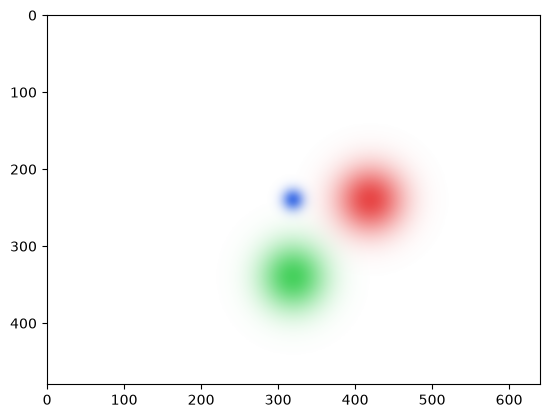

In [13]:
W, H, f = 640, 480, 500.0
K = torch.tensor([[f, 0, W / 2],
                  [0, f, H / 2],
                  [0, 0, 1]])

# World-to-camera: camera at (0, 0, -5) looking along +z.
world_to_cam = torch.tensor([[1.0, 0.0, 0.0, 0.0],
                             [0.0, 1.0, 0.0, 0.0],
                             [0.0, 0.0, 1.0, 5.0],
                             [0.0, 0.0, 0.0, 1.0]])


def render(s: Splats):
    """Render splats from the fixed camera. Returns (H, W, 3) on the CPU."""
    img, _, _ = rasterization(
        means=s.means.cuda(),
        quats=s.quats.cuda(),
        scales=s.log_scales.exp().cuda(),
        opacities=s.logit_opacities.sigmoid().cuda(),
        colors=s.colors.cuda(),
        viewmats=world_to_cam[None].cuda(),
        Ks=K[None].cuda(),
        width=W,
        height=H,
        backgrounds=torch.ones(1, 3).cuda(),
    )
    return img[0].clamp(0, 1).cpu()


plt.imshow(render(splats))
plt.show()

<img src="images/camera_and_world_frames.png" style="width: 1000px;">

## Gaussian Splatting training from scratch
First we load the train and test data. We need both the images and their poses

In [ ]:
# Load colmap results.
MODEL = "colmap_results/0_undistorted/sparse_txt"

# 1. cameras.txt stores one camera's intrinsics per line: CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[].
# For the PINHOLE model, PARAMS[] = fx, fy, cx, cy: focal lengths and principal point in pixels.
### No visualization ###


# 2. images.txt stores each image over two lines:
#    IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME
#    POINTS2D[] as (X, Y, POINT3D_ID)
images = read_images_txt(f"{MODEL}/images.txt")
print(f"{len(images)} images")


# 3. points3D.txt stores one triangulated point per line:
#    POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[] as (IMAGE_ID, POINT2D_IDX)
points = read_points3D_txt(f"{MODEL}/points3D.txt")
print(f"{len(points.ids)} points")

In [ ]:
TEST_EVERY = 8

cams = sorted(images.values(), key=lambda im: im.name)  # gsplat sorts by filename
train_cams = [im for i, im in enumerate(cams) if i % TEST_EVERY != 0]
val_cams = [im for i, im in enumerate(cams) if i % TEST_EVERY == 0]

step    0  L1 0.1063
step 1000  L1 0.0448
step 2000  L1 0.0650
step 3000  L1 0.0354
step 4000  L1 0.0339


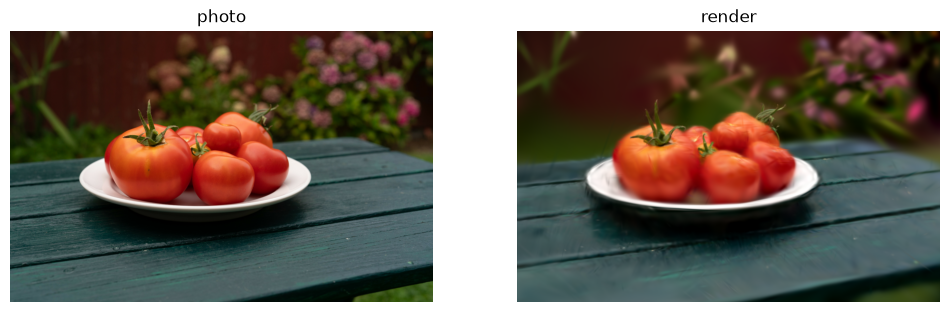

In [15]:
from dataclasses import fields
from pathlib import Path

import numpy as np
import pycolmap
from PIL import Image
from scipy.spatial import cKDTree

DATA = Path("colmap_results/0_undistorted")
rec = pycolmap.Reconstruction(DATA / "sparse")

views = []  # (viewmat, K, photo)
for im in rec.images.values():
    gt = torch.from_numpy(np.array(Image.open(DATA / "images_8_png" / Path(im.name).with_suffix(".png")).convert("RGB"))).float().cuda() / 255
    pose = im.cam_from_world() if callable(im.cam_from_world) else im.cam_from_world  # property in older pycolmap
    viewmat = torch.eye(4)
    viewmat[:3] = torch.from_numpy(pose.matrix())
    K = torch.from_numpy(rec.cameras[im.camera_id].calibration_matrix()).float()
    K[:2] *= gt.shape[1] / rec.cameras[im.camera_id].width  # intrinsics are for full resolution
    views.append((viewmat.cuda(), K.cuda(), gt))

# One splat per SfM point, sized by the RMS distance to its 3 nearest neighbors
xyz = np.stack([p.xyz for p in rec.points3D.values()])
dist = np.sqrt((cKDTree(xyz).query(xyz, k=4)[0][:, 1:] ** 2).mean(1)).clip(1e-7)
N = len(xyz)
model = Splats(
    means=torch.tensor(xyz).float(),
    quats=torch.tensor([1.0, 0.0, 0.0, 0.0]).repeat(N, 1),
    log_scales=torch.tensor(dist).float().log()[:, None].repeat(1, 3),
    logit_opacities=torch.logit(torch.full((N,), 0.1)),
    colors=torch.tensor(np.stack([p.color for p in rec.points3D.values()]) / 255).float(),
)
for f in fields(model):
    setattr(model, f.name, getattr(model, f.name).cuda().requires_grad_())

# Per-field learning rates from the 3DGS paper; means move in world units, so theirs scales with the scene
centers = torch.stack([v.inverse()[:3, 3] for v, _, _ in views])
scene_scale = 1.1 * (centers - centers.mean(0)).norm(dim=1).max().item()
lrs = {"means": 1.6e-4 * scene_scale, "quats": 1e-3, "log_scales": 5e-3, "logit_opacities": 5e-2, "colors": 2.5e-3}
opt = torch.optim.Adam([{"params": [getattr(model, k)], "lr": lr} for k, lr in lrs.items()], eps=1e-15)


def render(s, viewmat, K, gt):
    return rasterization(
        s.means, s.quats, s.log_scales.exp(), torch.sigmoid(s.logit_opacities), s.colors,
        viewmat[None], K[None], gt.shape[1], gt.shape[0],
    )[0][0]


for step in range(5000):
    viewmat, K, gt = views[np.random.randint(len(views))]
    loss = (render(model, viewmat, K, gt) - gt).abs().mean()  # L1
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 1000 == 0:
        print(f"step {step:4d}  L1 {loss.item():.4f}")

viewmat, K, gt = views[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, im, title in zip(axes, [gt, render(model, viewmat, K, gt).detach()], ["photo", "render"]):
    ax.imshow(im.clamp(0, 1).cpu())
    ax.set_title(title)
    ax.axis("off")
plt.show()